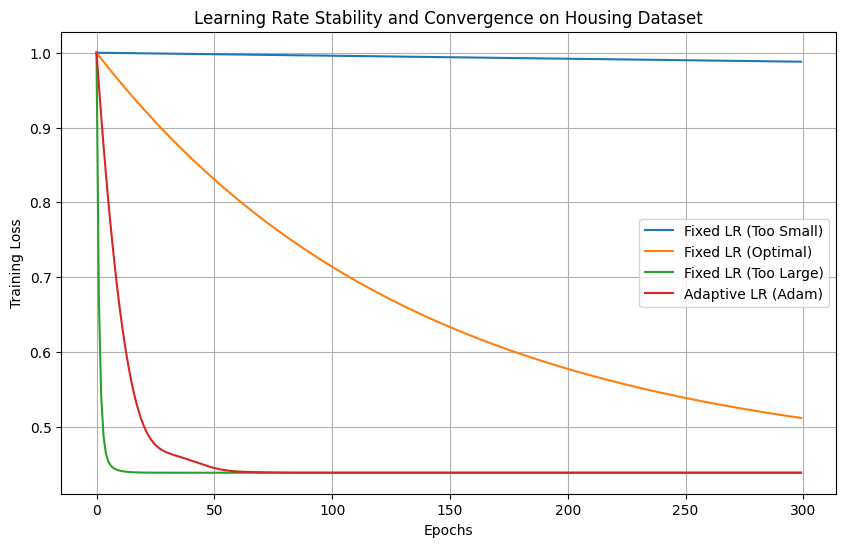

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load Dataset
# -----------------------------
df = pd.read_csv("Housing.csv")

# target column
target = "price"

# keep only numeric columns
df = df.select_dtypes(include=[np.number]).dropna()

X = df.drop(columns=[target]).values
y = df[target].values.reshape(-1, 1)

# -----------------------------
# 2. Feature Scaling
# -----------------------------
X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)
y = (y - y.mean()) / (y.std() + 1e-8)

# Add bias term
X = np.hstack([np.ones((X.shape[0], 1)), X])

# -----------------------------
# 3. Gradient Descent Function
# -----------------------------
def gradient_descent(lr, epochs=300):
    w = np.zeros((X.shape[1], 1))
    losses = []

    for _ in range(epochs):
        y_pred = X @ w
        error = y_pred - y

        loss = np.mean(error ** 2)
        gradient = 2 * X.T @ error / len(X)

        w -= lr * gradient
        losses.append(loss)

    return losses


# -----------------------------
# 4. Adam Optimizer
# -----------------------------
def adam_optimizer(lr=0.01, epochs=300,
                   beta1=0.9, beta2=0.999, eps=1e-8):

    w = np.zeros((X.shape[1], 1))
    m = np.zeros_like(w)
    v = np.zeros_like(w)

    losses = []

    for t in range(1, epochs + 1):

        y_pred = X @ w
        error = y_pred - y
        loss = np.mean(error ** 2)

        grad = 2 * X.T @ error / len(X)

        m = beta1*m + (1-beta1)*grad
        v = beta2*v + (1-beta2)*(grad**2)

        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)

        w -= lr * m_hat / (np.sqrt(v_hat) + eps)

        losses.append(loss)

    return losses


# -----------------------------
# 5. Train with Different LR
# -----------------------------
loss_small = gradient_descent(lr=1e-5)
loss_optimal = gradient_descent(lr=1e-3)
loss_large = gradient_descent(lr=0.1)
loss_adam = adam_optimizer(lr=0.01)

# -----------------------------
# 6. Plot Graph
# -----------------------------
plt.figure(figsize=(10,6))

plt.plot(loss_small, label="Fixed LR (Too Small)")
plt.plot(loss_optimal, label="Fixed LR (Optimal)")
plt.plot(loss_large, label="Fixed LR (Too Large)")
plt.plot(loss_adam, label="Adaptive LR (Adam)")

plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Learning Rate Stability and Convergence on Housing Dataset")

plt.legend()
plt.grid(True)
plt.show()